# Arema Predictions

A notebook to explore different arema models and their variations.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rt_df = pd.read_parquet("../data-pull/combined_data/rtm_data_2023_2026.parquet")
rt_df.head()

,interval_end_utc,market,location,location_type,lmp,energy,congestion,loss,year
0,2023-03-24 20:05:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,23.07,25.67,-1.86,-0.74,2023
1,2023-03-25 01:05:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,25.06,25.29,-0.59,0.36,2023
2,2023-03-25 01:10:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,25.02,24.55,-0.14,0.61,2023
3,2023-03-25 01:15:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,24.79,24.47,-0.51,0.83,2023
4,2023-03-25 01:20:00+00:00,REAL_TIME_5_MIN,MINN.HUB,Hub,24.32,24.03,-0.45,0.74,2023


## Preparing Dataset

In the future we will likely want to do a log transform on the model. This is just to get a baseline for how AREMA works.

                             lmp
interval_end_utc                
2023-03-24 20:05:00+00:00  23.07
2023-03-25 01:05:00+00:00  25.06
2023-03-25 01:10:00+00:00  25.02
2023-03-25 01:15:00+00:00  24.79
2023-03-25 01:20:00+00:00  24.32                              lmp
interval_end_utc                
2026-01-06 05:15:00+00:00  22.19
2026-01-06 05:20:00+00:00  22.69
2026-01-06 05:25:00+00:00  22.52
2026-01-06 05:30:00+00:00  20.55
2026-01-06 05:35:00+00:00  21.01


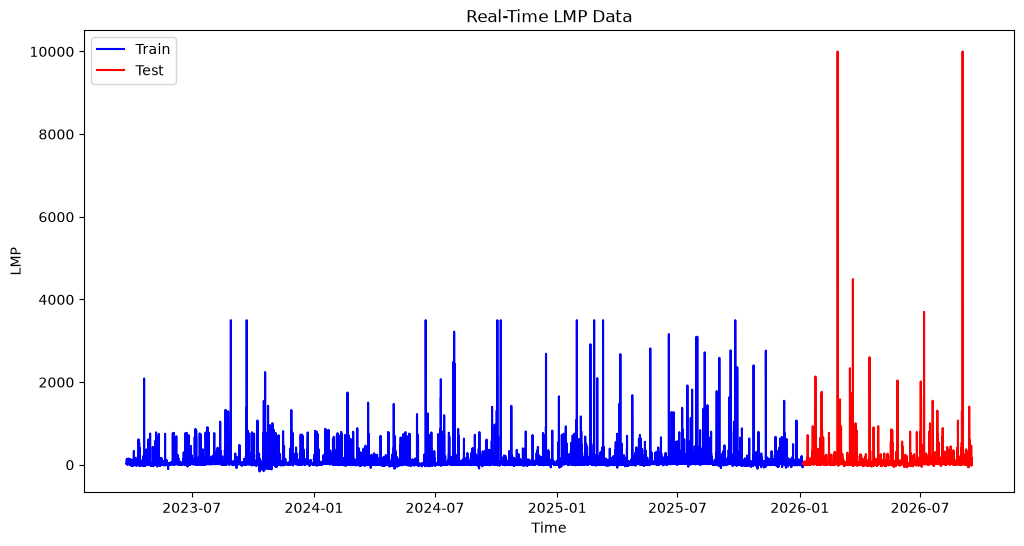

In [ ]:
df = pd.DataFrame({
    "lmp": rt_df["lmp"].tolist()},
    index=rt_df["interval_end_utc"])

# Splitting data
train_size = int(0.8 * len(df))
train, test = df.iloc[:train_size], df.iloc[train_size:]
#print(train.head(), test.head())

# Visualizing the data
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Test', color='red')
plt.xlabel('Time')
plt.ylabel('LMP')
plt.title('Real-Time LMP Data')
plt.legend()
plt.show()

## Finding best parameters

statsmodels and pmdarima are used for time series analysis


In [13]:
from pmdarima import auto_arima

In [15]:
# Auto-fit ARIMA parameters
stepwise_fit = auto_arima(
    train["lmp"], 
    start_p=1, start_q=1, 
    max_p=5, max_q=5, 
    m=1,               # Set m=1 for non-seasonal data
    d=None,            # Let the algorithm automatically find 'd'
    seasonal=False, 
    trace=True
)

print(stepwise_fit.summary())
# Let's assume it chooses an order, e.g., (1, 1, 1)
best_order = stepwise_fit.order 
print(f"Optimal (p, d, q) Order: {best_order}")

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3053206.127, Time=47.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3116246.971, Time=2.55 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3089932.325, Time=3.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3075456.440, Time=20.51 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3116244.971, Time=1.40 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3050505.591, Time=95.91 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=3079665.911, Time=8.63 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3049683.543, Time=123.87 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=3075331.123, Time=6.40 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=156.50 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3049810.046, Time=222.00 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=176.71 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=3071904.328, Time=8.74 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=3049687.267, Time=128.9

To avoid running above cell again (30 mins): Optimal (p, d, q) Order: (3, 1, 2)

## Build and fit model

In [16]:
from statsmodels.tsa.arima.model import ARIMA

In [24]:
print(best_order)

(3, 1, 2)


In [19]:
# Initialize and fit the model
model = ARIMA(train["lmp"], order=best_order)
model_fitted = model.fit()

# View statistical insights
print(model_fitted.summary())

c:\Users\krawz\Courses\Fall2026\capstone\data-science-capstone\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\krawz\Courses\Fall2026\capstone\data-science-capstone\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\krawz\Courses\Fall2026\capstone\data-science-capstone\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
c:\Users\krawz\Courses\Fall2026\capstone\data-science-capstone\.venv\Lib\site-packages\statsmodels\tsa\sta

                               SARIMAX Results                                
Dep. Variable:                    lmp   No. Observations:               288578
Model:                 ARIMA(3, 1, 2)   Log Likelihood            -1524796.855
Date:                Wed, 30 Sep 2026   AIC                        3049605.710
Time:                        11:49:11   BIC                        3049669.146
Sample:                             0   HQIC                       3049624.088
                             - 288578                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9113      0.004    215.715      0.000       0.903       0.920
ar.L2         -0.1225      0.002    -57.800      0.000      -0.127      -0.118
ar.L3          0.0093      0.001     17.539      0.0

In [28]:
train.index

DatetimeIndex(['2023-03-24 20:05:00+00:00', '2023-03-25 01:05:00+00:00',
               '2023-03-25 01:10:00+00:00', '2023-03-25 01:15:00+00:00',
               '2023-03-25 01:20:00+00:00', '2023-03-25 01:25:00+00:00',
               '2023-03-25 01:30:00+00:00', '2023-03-25 01:35:00+00:00',
               '2023-03-25 01:40:00+00:00', '2023-03-25 01:45:00+00:00',
               ...
               '2026-01-06 04:25:00+00:00', '2026-01-06 04:30:00+00:00',
               '2026-01-06 04:35:00+00:00', '2026-01-06 04:40:00+00:00',
               '2026-01-06 04:45:00+00:00', '2026-01-06 04:50:00+00:00',
               '2026-01-06 04:55:00+00:00', '2026-01-06 05:00:00+00:00',
               '2026-01-06 05:05:00+00:00', '2026-01-06 05:10:00+00:00'],
              dtype='datetime64[ns, UTC]', name='interval_end_utc', length=288578, freq=None)

In [30]:
predicted = model_fitted.get_forecast(test.index).predicted_mean  # Predicting for the next 5 intervals
rmse = np.sqrt(np.mean((test["lmp"] - predicted)**2))
print(f"RMSE: {rmse}")

InvalidIndexError: DatetimeIndex(['2026-01-06 05:15:00+00:00', '2026-01-06 05:20:00+00:00',
               '2026-01-06 05:25:00+00:00', '2026-01-06 05:30:00+00:00',
               '2026-01-06 05:35:00+00:00', '2026-01-06 05:40:00+00:00',
               '2026-01-06 05:45:00+00:00', '2026-01-06 05:50:00+00:00',
               '2026-01-06 05:55:00+00:00', '2026-01-06 06:00:00+00:00',
               ...
               '2026-09-16 23:15:00+00:00', '2026-09-16 23:20:00+00:00',
               '2026-09-16 23:25:00+00:00', '2026-09-16 23:30:00+00:00',
               '2026-09-16 23:35:00+00:00', '2026-09-16 23:40:00+00:00',
               '2026-09-16 23:45:00+00:00', '2026-09-16 23:50:00+00:00',
               '2026-09-16 23:55:00+00:00', '2026-09-17 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='interval_end_utc', length=72145, freq=None)

Data start: 2023-03-24 20:05:00+00:00
Data end: 2026-09-17 00:00:00+00:00


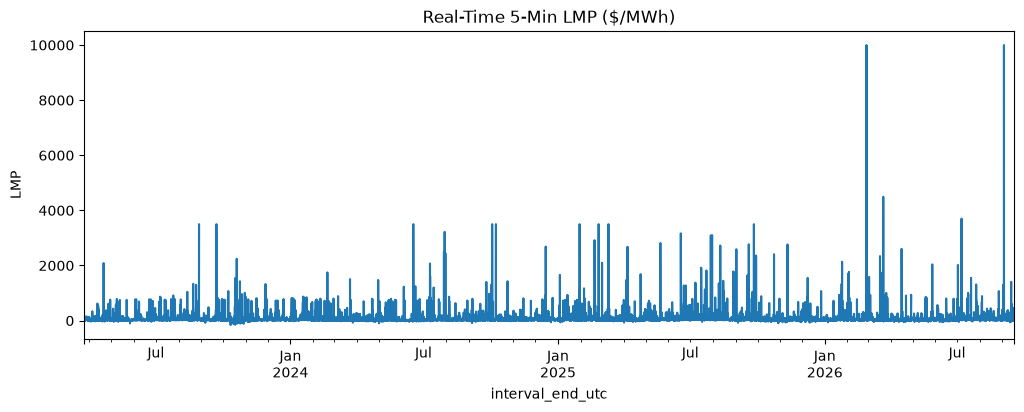

                               SARIMAX Results                                
Dep. Variable:                    lmp   No. Observations:                 2016
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -10599.799
Date:                Wed, 30 Sep 2026   AIC                          21205.598
Time:                        19:15:48   BIC                          21222.423
Sample:                    09-10-2026   HQIC                         21211.774
                         - 09-17-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7658      0.003    238.384      0.000       0.759       0.772
ma.L1         -0.9925      0.002   -634.498      0.000      -0.996      -0.989
sigma2      2168.7229      7.478    290.001      0.0

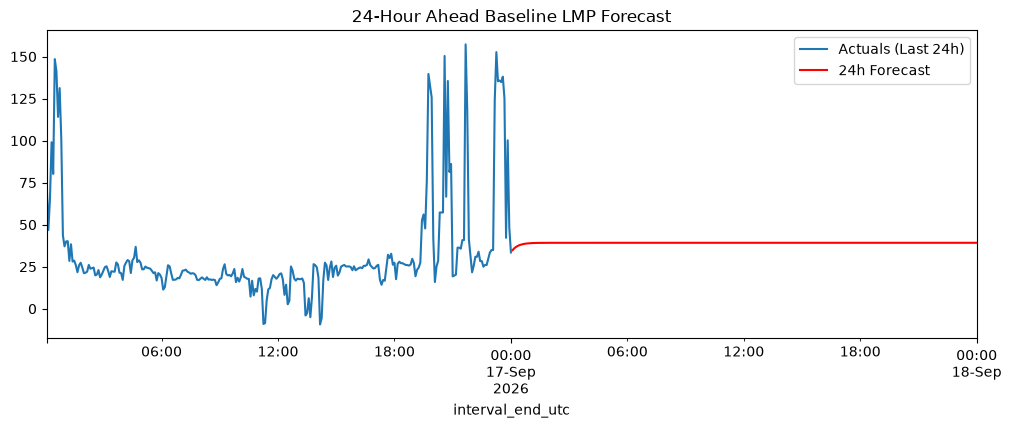

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Convert timestamps and set index
rt_df['interval_end_utc'] = pd.to_datetime(rt_df['interval_end_utc'])
lmp_series = rt_df.set_index('interval_end_utc')['lmp'].sort_index()

# 2. Handle duplicate timestamps (if any) and set a strict 5-minute frequency
lmp_series = lmp_series[~lmp_series.index.duplicated(keep='first')]
lmp_series = lmp_series.asfreq('5min').ffill()

# Display range
print("Data start:", lmp_series.index.min())
print("Data end:", lmp_series.index.max())

# 3. Plot the series
plt.figure(figsize=(12, 4))
lmp_series.plot(title="Real-Time 5-Min LMP ($/MWh)")
plt.ylabel("LMP")
plt.show()

# 4. Fit a baseline ARIMA(1, 1, 1) model
# For initial testing, run on a smaller subset (e.g., last 7 days = 2,016 intervals)
train_subset = lmp_series.tail(288 * 7)

model = ARIMA(train_subset, order=(1, 1, 1))
model_fit = model.fit()

# Print summary
print(model_fit.summary())

# 5. Baseline 24-hour forecast (288 five-minute intervals)
forecast_24h = model_fit.forecast(steps=288)

plt.figure(figsize=(12, 4))
train_subset.tail(288).plot(label="Actuals (Last 24h)")
forecast_24h.plot(label="24h Forecast", color="red")
plt.title("24-Hour Ahead Baseline LMP Forecast")
plt.legend()
plt.show()